In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sklearn

features = pd.read_csv('../features.csv')
database = pd.read_csv('../nanopore_trace_database.csv')

# Visualization of Mean Current Distribution and other features to see what features can be used for classification

### Mean Current

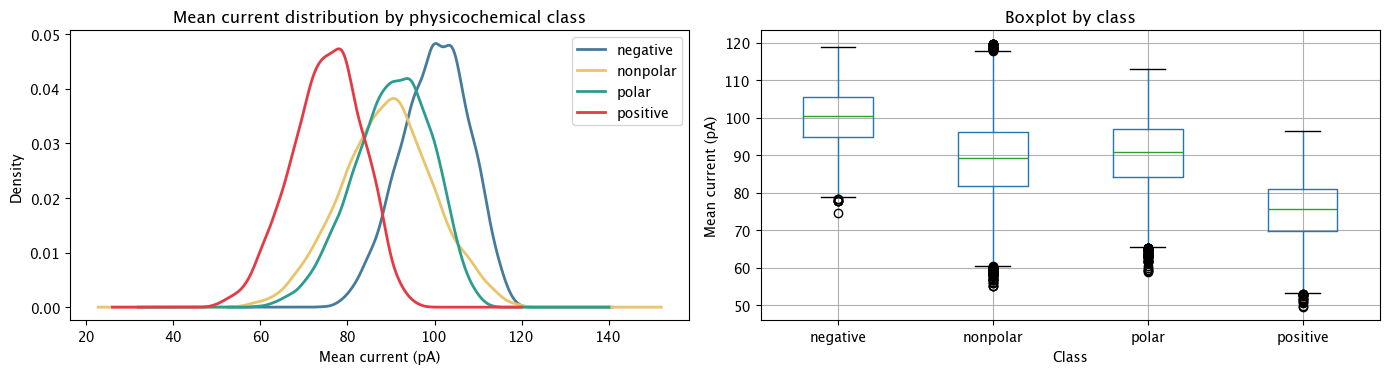

              count    mean    std    min    25%     50%     75%     max
phys_class                                                              
negative     3974.0  100.02   7.68  74.65  94.74  100.36  105.57  118.77
nonpolar    18040.0   89.09  10.68  55.05  81.90   89.31   96.27  119.77
polar       14008.0   90.25   8.97  58.96  84.27   90.77   96.86  113.06
positive     3973.0   75.21   8.06  49.48  69.83   75.65   80.90   96.51


In [55]:
CLASS_COLORS = {
    'positive': '#e63946',
    'negative': '#457b9d',
    'polar':    '#2a9d8f',
    'nonpolar': '#e9c46a',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE per class overlaid
ax = axes[0]
for cls, grp in features.groupby('phys_class'):
    grp['mean_current'].plot.kde(ax=ax, label=cls, color=CLASS_COLORS[cls], linewidth=2)
ax.set_xlabel('Mean current (pA)')
ax.set_title('Mean current distribution by physicochemical class')
ax.legend()

# Right: boxplot per class
ax = axes[1]
order = ['positive', 'negative', 'polar', 'nonpolar']
features.boxplot(column='mean_current', by='phys_class', ax=ax,
           positions=range(len(order)), labels=order)
ax.set_xlabel('Class')
ax.set_ylabel('Mean current (pA)')
ax.set_title('Boxplot by class')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Print summary stats
print(features.groupby('phys_class')['mean_current'].describe().round(2))

### Standard Deviation

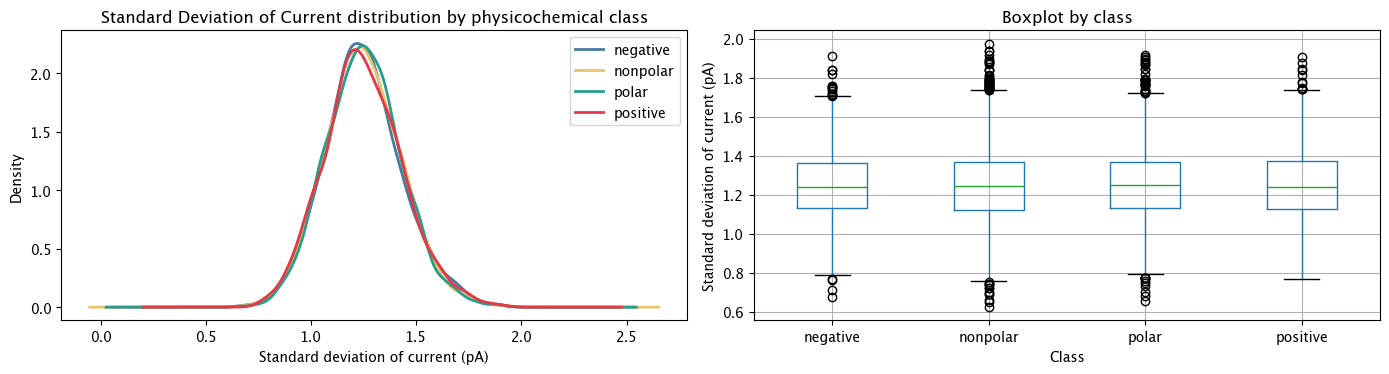

             count  mean   std   min   25%   50%   75%   max
phys_class                                                  
negative    1201.0  1.25  0.18  0.67  1.13  1.24  1.36  1.91
nonpolar    5423.0  1.25  0.18  0.62  1.12  1.24  1.37  1.98
polar       4123.0  1.25  0.18  0.66  1.13  1.25  1.37  1.92
positive    1224.0  1.25  0.19  0.77  1.13  1.24  1.37  1.91


In [29]:
CLASS_COLORS = {
    'positive': '#e63946',
    'negative': '#457b9d',
    'polar':    '#2a9d8f',
    'nonpolar': '#e9c46a',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE per class overlaid
ax = axes[0]
for cls, grp in features.groupby('phys_class'):
    grp['std_current'].plot.kde(ax=ax, label=cls, color=CLASS_COLORS[cls], linewidth=2)
ax.set_xlabel('Standard deviation of current (pA)')
ax.set_title('Standard Deviation of Current distribution by physicochemical class')
ax.legend()

# Right: boxplot per class
ax = axes[1]
order = ['positive', 'negative', 'polar', 'nonpolar']
features.boxplot(column='std_current', by='phys_class', ax=ax,
           positions=range(len(order)), labels=order)
ax.set_xlabel('Class')
ax.set_ylabel('Standard deviation of current (pA)')
ax.set_title('Boxplot by class')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Print summary stats
print(features.groupby('phys_class')['std_current'].describe().round(2))

### Dwell Time

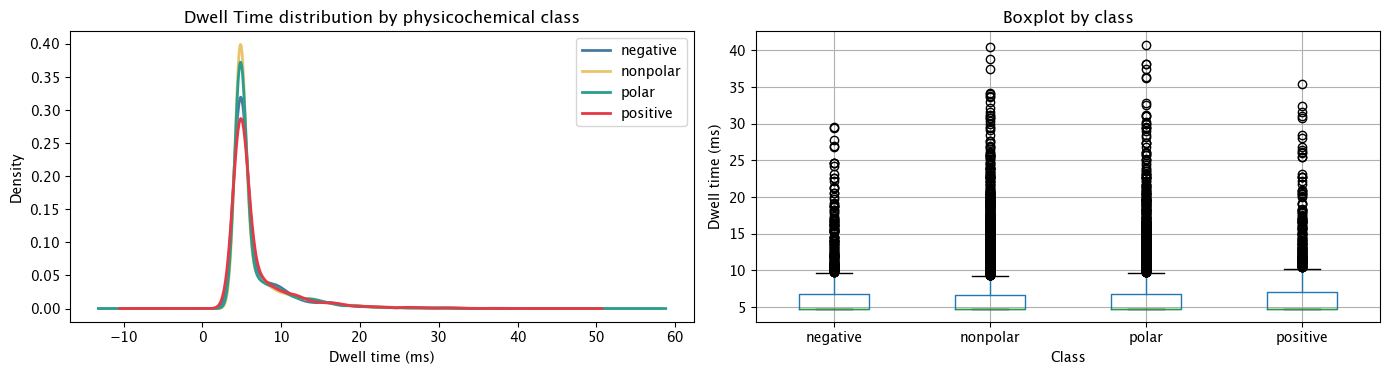

             count  mean   std  min  25%  50%  75%   max
phys_class                                              
negative    1201.0  6.58  3.64  4.8  4.8  4.8  6.8  29.6
nonpolar    5423.0  6.62  3.89  4.8  4.8  4.8  6.6  40.4
polar       4123.0  6.67  3.94  4.8  4.8  4.8  6.8  40.8
positive    1224.0  6.75  4.04  4.8  4.8  4.8  7.0  35.4


In [30]:
CLASS_COLORS = {
    'positive': '#e63946',
    'negative': '#457b9d',
    'polar':    '#2a9d8f',
    'nonpolar': '#e9c46a',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE per class overlaid
ax = axes[0]
for cls, grp in features.groupby('phys_class'):
    grp['dwell_time'].plot.kde(ax=ax, label=cls, color=CLASS_COLORS[cls], linewidth=2)
ax.set_xlabel('Dwell time (ms)')
ax.set_title('Dwell Time distribution by physicochemical class')
ax.legend()

# Right: boxplot per class
ax = axes[1]
order = ['positive', 'negative', 'polar', 'nonpolar']
features.boxplot(column='dwell_time', by='phys_class', ax=ax,
           positions=range(len(order)), labels=order)
ax.set_xlabel('Class')
ax.set_ylabel('Dwell time (ms)')
ax.set_title('Boxplot by class')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Print summary stats
print(features.groupby('phys_class')['dwell_time'].describe().round(2))

# Define order and mapping of classes and corresponding colors

In [31]:
# color mapping for 4 amino acid classes
CLASS_COLORS_4 = {
    'nonpolar': 'steelblue',
    'polar': 'orange',
    'positive': 'green',
    'negative': 'red'
}

CLASS_COLORS_3 = {
    'positive': 'green',
    'negative': 'red',
    'other': 'grey'

}

ORDER_4 = ['positive','nonpolar','polar','negative']

ORDER_3 = ['positive','negative','other']



### Map both nonpolar and polar amino aicds to the 'other' class based on current distribution

In [32]:
features['class3'] = features['phys_class'].replace({'polar': 'other', 'nonpolar': 'other'})
features['phys_class']

0           polar
1        negative
2           polar
3        nonpolar
4           polar
           ...   
11966    nonpolar
11967       polar
11968    nonpolar
11969    positive
11970    nonpolar
Name: phys_class, Length: 11971, dtype: str

<Axes: xlabel='mean_current', ylabel='Density'>

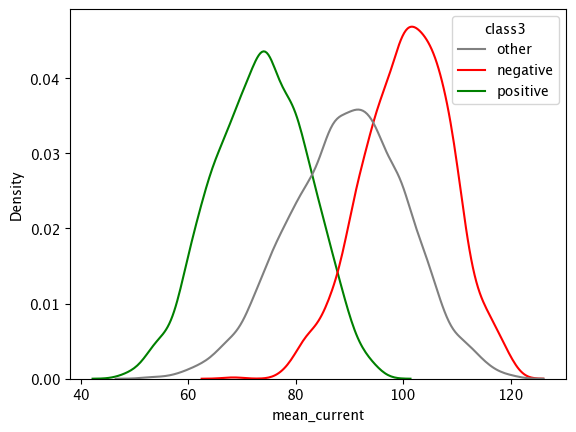

In [33]:
sns.kdeplot(data=features, x = 'mean_current', hue='class3', palette=CLASS_COLORS_3, common_norm=False)

### Violin plot — 3 classes ordered by median

/var/folders/ck/1nxbm2p53kx6t3f6p6jhsfxc0000gn/T/ipykernel_85037/2936736022.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


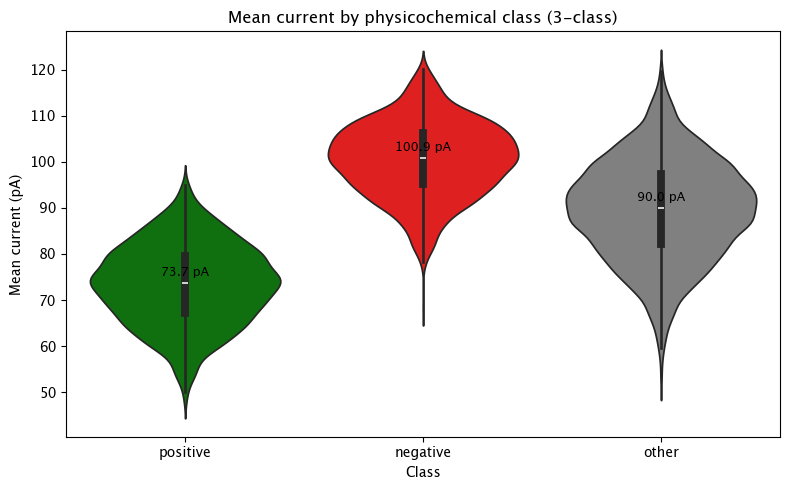

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.violinplot(
    data=features, x='class3', y='mean_current',
    order=ORDER_3, palette=CLASS_COLORS_3, ax=ax
)

# annotate medians
for i, cls in enumerate(ORDER_3):
    median = features.loc[features['class3'] == cls, 'mean_current'].median()
    ax.text(i, median + 1, f'{median:.1f} pA', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Mean current by physicochemical class (3-class)')
ax.set_xlabel('Class')
ax.set_ylabel('Mean current (pA)')
plt.tight_layout()
plt.show()

### Summary statistics per class

In [35]:
stats_table = features.groupby('class3')['mean_current'].agg(
    n='count',
    mean='mean',
    std='std',
    p5=lambda x: x.quantile(0.05),
    p25=lambda x: x.quantile(0.25),
    median='median',
    p75=lambda x: x.quantile(0.75),
    p95=lambda x: x.quantile(0.95),
).loc[ORDER_3].round(2)

stats_table

,n,mean,std,p5,p25,median,p75,p95
class3,,,,,,,,
positive,1224,73.40,8.67,59.32,67.24,73.73,79.64,87.35
negative,1201,100.59,8.11,86.47,95.09,100.93,106.26,113.34
other,9546,89.61,10.91,71.37,82.17,90.03,97.28,106.91


### Scatter of std_current and dwell_time by class — no discriminative signal

In [36]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# for cls in ORDER_3:
#     subset = features[features['class3'] == cls]
#     axes[0].scatter(subset['mean_current'], subset['std_current'],
#                     color=CLASS_COLORS_3[cls], alpha=0.2, s=5, label=cls)
#     axes[1].scatter(subset['mean_current'], subset['dwell_time'],
#                     color=CLASS_COLORS_3[cls], alpha=0.2, s=5, label=cls)

# axes[0].set_xlabel('Mean current (pA)')
# axes[0].set_ylabel('Std current')
# axes[0].set_title('std_current vs mean_current')
# axes[0].legend()

# axes[1].set_xlabel('Mean current (pA)')
# axes[1].set_ylabel('Dwell time')
# axes[1].set_title('dwell_time vs mean_current')
# axes[1].legend()

# plt.tight_layout()
# plt.show()

### KDE overlap quantification between class pairs

In [37]:
from scipy.stats import gaussian_kde
from itertools import combinations

x = np.linspace(features['mean_current'].min() - 5, features['mean_current'].max() + 5, 1000)

# fit a KDE per class
kdes = {}
for cls in ORDER_3:
    vals = features.loc[features['class3'] == cls, 'mean_current'].values
    kdes[cls] = gaussian_kde(vals)(x)

# compute pairwise overlap
print("Pairwise KDE overlap (0 = no overlap, 1 = identical):")
for cls_a, cls_b in combinations(ORDER_3, 2):
    overlap = np.trapezoid(np.minimum(kdes[cls_a], kdes[cls_b]), x)
    print(f"  {cls_a} vs {cls_b}: {overlap:.4f}")

Pairwise KDE overlap (0 = no overlap, 1 = identical):
  positive vs negative: 0.1192
  positive vs other: 0.4224
  negative vs other: 0.5741


# See if i can use grid search to find thresholds for cutting off positive, negative, and other current

In [14]:
# classify a step with two cut-off values

# if mean_current < t1: classify as positive
# if mean_current > t2: classify as negative
# else classify as other


# do a grid search to find optimal t1 and t2 that maximize classification accuracy

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

t1range = np.arange(40, 100, 0.5)
t2range = np.arange(60, 130, 0.5)
best_acc = 0
best_t1, best_t2 = None, None

conditions = [
    features['mean_current'] < best_t1,
    features['mean_current'] > best_t2
]
choices = ['positive', 'negative']
preds = np.select(conditions, choices, default='other'
                  )




for t1 in t1range:
    for t2 in t2range:
        if t1>=t2:
            continue
        conditions = [
            features['mean_current'] < t1,
            features['mean_current'] > t2
            ]
        choices = ['positive', 'negative']
        preds = np.select(conditions, choices, default='other'
                  )
        score = f1_score(features['class3'], preds, average='weighted')
        if score >best_acc:
            best_acc = score 
            best_t1, best_t2 = t1, t2


print(f"Best F1 score: {best_acc:.4f} with t1={best_t1} and t2={best_t2}")

        # need to apply the thresholds to generate predicitons for every row
        # score them against the true labels
        # track the best score

Best F1 score: 0.7680 with t1=71.0 and t2=107.5


## Final classification report using the final predictions generated with the best t1 and t2 w the grid search

In [15]:
conditions = [
    features['mean_current'] < best_t1,
    features['mean_current'] > best_t2,
]
final_preds = np.select(conditions, ['positive', 'negative'], default='other')

print(classification_report(features['class3'], final_preds))


              precision    recall  f1-score   support

    negative       0.38      0.21      0.27      1201
       other       0.84      0.91      0.87      9546
    positive       0.52      0.39      0.44      1224

    accuracy                           0.79     11971
   macro avg       0.58      0.50      0.53     11971
weighted avg       0.76      0.79      0.77     11971



<Axes: >

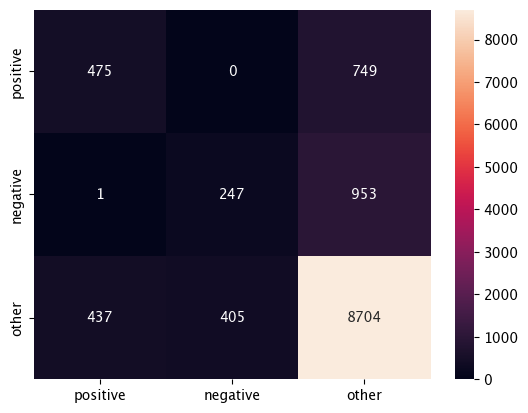

In [16]:
cm = confusion_matrix(features['class3'], final_preds, labels=ORDER_3)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=ORDER_3, yticklabels=ORDER_3)

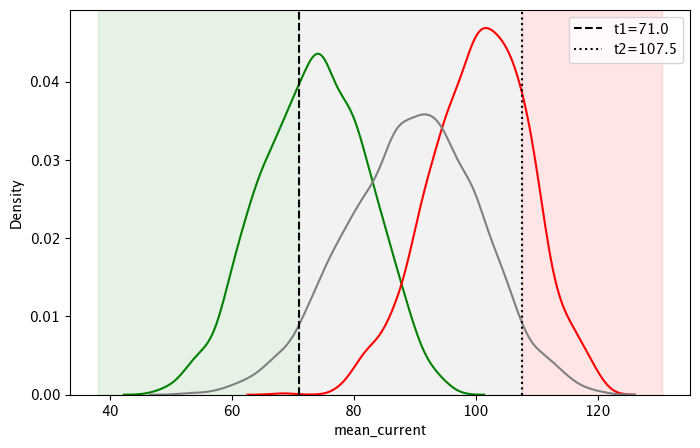

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

# KDE
sns.kdeplot(data=features, x='mean_current', hue='class3', 
            palette=CLASS_COLORS_3, common_norm=False, ax=ax)

# threshold lines
ax.axvline(best_t1, color='black', linestyle='--', label=f't1={best_t1:.1f}')
ax.axvline(best_t2, color='black', linestyle=':',  label=f't2={best_t2:.1f}')

# shaded decision regions
ax.axvspan(ax.get_xlim()[0], best_t1, alpha=0.1, color=CLASS_COLORS_3['positive'])
ax.axvspan(best_t1, best_t2,           alpha=0.1, color=CLASS_COLORS_3['other'])
ax.axvspan(best_t2, ax.get_xlim()[1], alpha=0.1, color=CLASS_COLORS_3['negative'])

ax.legend()
plt.show()

In [42]:
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = features[['mean_current']].values
y = features['class3'].values

models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced'))
    ]),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
}

### Classifying with machine elarning models instead, with 5-fold cross validation


* used a Gaussian Naive Bayes Classifer, Random Forest Classifier, and Logistic Regression(???)



In [43]:
from sklearn.model_selection import StratifiedKFold, cross_validate

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'macro_f1':    'f1_macro',
    'weighted_f1': 'f1_weighted',
    'accuracy':    'accuracy',
}

cv_results = {}
for name, model in models.items():
    result = cross_validate(model, X, y, cv=kf, scoring=scoring)
    cv_results[name] = {
        'macro F1':    (result['test_macro_f1'].mean(),    result['test_macro_f1'].std()),
        'weighted F1': (result['test_weighted_f1'].mean(), result['test_weighted_f1'].std()),
        'accuracy':    (result['test_accuracy'].mean(),    result['test_accuracy'].std()),
    }

# summary table: mean ± std across folds
rows = {}
for name, metrics in cv_results.items():
    rows[name] = {metric: f"{mean:.3f} ± {std:.3f}" for metric, (mean, std) in metrics.items()}

pd.DataFrame(rows).T

,macro F1,weighted F1,accuracy
GaussianNB,0.413 ± 0.010,0.744 ± 0.004,0.804 ± 0.002
LogisticRegression,0.472 ± 0.007,0.570 ± 0.008,0.528 ± 0.008
RandomForest,0.446 ± 0.009,0.705 ± 0.007,0.708 ± 0.008


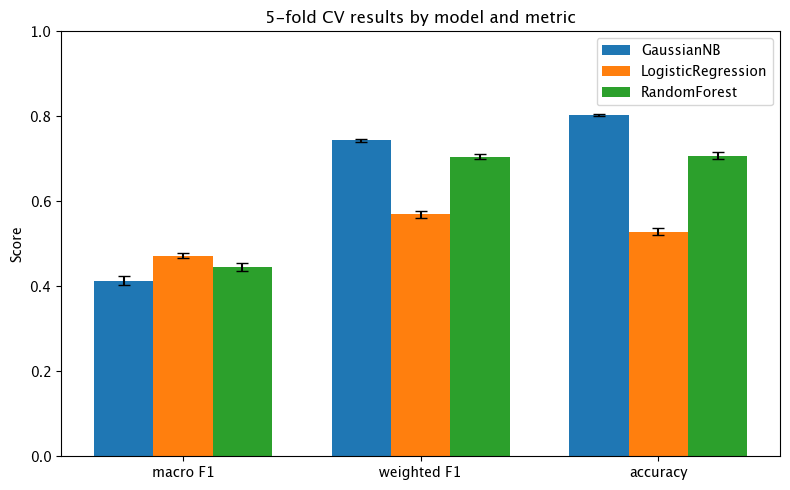

In [44]:
metrics = ['macro F1', 'weighted F1', 'accuracy']
model_names = list(cv_results.keys())
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

for i, name in enumerate(model_names):
    means = [cv_results[name][m][0] for m in metrics]
    stds  = [cv_results[name][m][1] for m in metrics]
    ax.bar(x + i * width, means, width, yerr=stds, label=name, capsize=4)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('5-fold CV results by model and metric')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

#### Visualize the diference ins euqnec eof the peptide

In [45]:
from sklearn.model_selection import cross_val_predict

# get out-of-fold predictions for each model using the same CV split
for name, model in models.items():
    features[f'pred_{name}'] = cross_val_predict(model, X, y, cv=kf)

# show one trace as an example
trace = features[features['trace_id'] == 0].sort_values('step_id')
for name in models:
    acc = (trace[f'pred_{name}'] == trace['class3']).mean()
    print(f"{name:20s} (acc={acc:.2f}): {' - '.join(trace[f'pred_{name}'].tolist())}")
print(f"{'actual':20s}         : {' - '.join(trace['class3'].tolist())}")
print(f"{'amino acid':20s}         : {' - '.join(trace['amino_acid'].tolist())}")

GaussianNB           (acc=0.80): other - other - other - other - positive - other - other - other - other - other - other - other - other - other - other - other - other - other - other - other
LogisticRegression   (acc=0.35): negative - negative - other - positive - positive - positive - positive - positive - other - negative - other - other - negative - negative - negative - negative - negative - negative - negative - negative
RandomForest         (acc=0.85): negative - other - other - other - other - positive - other - other - other - other - other - other - other - negative - other - other - other - other - negative - other
actual                       : other - negative - other - other - other - positive - other - other - other - other - other - other - other - negative - other - other - other - other - other - other
amino acid                   : S - D - Q - W - Y - K - T - W - Q - G - F - P - M - D - G - N - G - S - T - P


Diff way to visualize the diffs in sequence of classes of the peptides

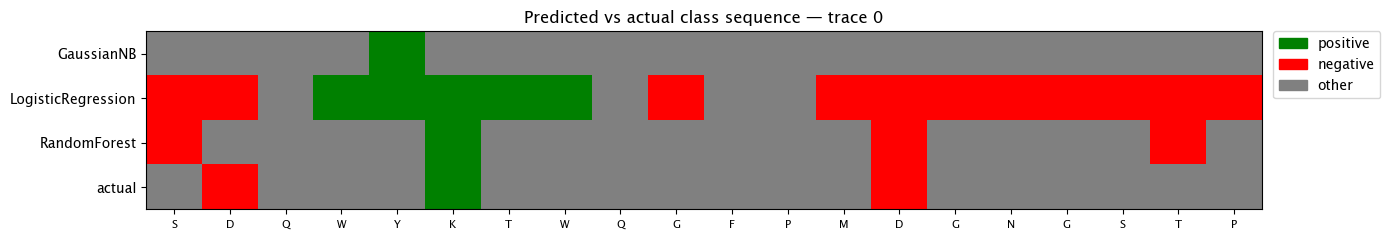

In [46]:
import matplotlib
from matplotlib.patches import Patch

CLASS_INT = {'positive': 0, 'other': 1, 'negative': 2}
CMAP = matplotlib.colors.ListedColormap([CLASS_COLORS_3['positive'], CLASS_COLORS_3['other'], CLASS_COLORS_3['negative']])

rows = {name: trace[f'pred_{name}'].map(CLASS_INT).values for name in models}
rows['actual'] = trace['class3'].map(CLASS_INT).values
grid = np.array(list(rows.values()))

fig, ax = plt.subplots(figsize=(14, 2.5))
ax.imshow(grid, aspect='auto', cmap=CMAP, vmin=0, vmax=2, interpolation='none')

ax.set_yticks(range(len(rows)))
ax.set_yticklabels(list(rows.keys()))
ax.set_xticks(range(len(trace)))
ax.set_xticklabels(trace['amino_acid'].tolist(), fontsize=8)

legend = [Patch(color=CLASS_COLORS_3[c], label=c) for c in ORDER_3]
ax.legend(handles=legend, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

ax.set_title('Predicted vs actual class sequence — trace 0')
plt.tight_layout()
plt.show()

#### Accuracy of each amino acid classified per model

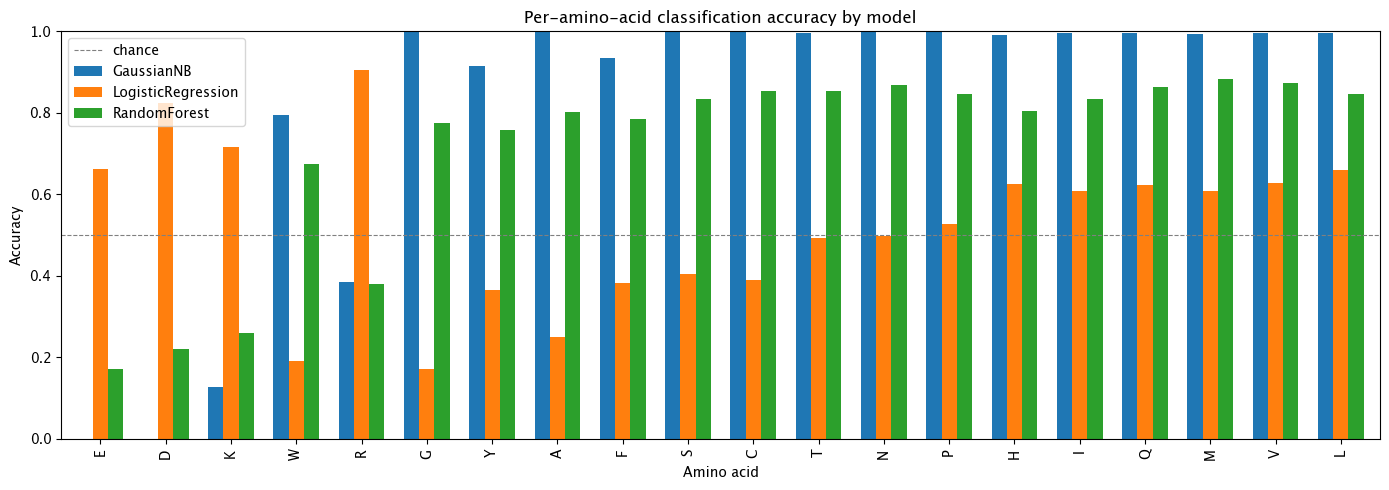

In [47]:
aa_acc = {}
for name in models:
    aa_acc[name] = (
        features.groupby('amino_acid')
        .apply(lambda df: (df[f'pred_{name}'] == df['class3']).mean())
        .rename(name)
    )

aa_df = pd.concat(aa_acc, axis=1)

# sort by mean accuracy across models (worst performers on the left)
aa_df = aa_df.loc[aa_df.mean(axis=1).sort_values().index]

ax = aa_df.plot(kind='bar', figsize=(14, 5), width=0.7)
ax.set_xlabel('Amino acid')
ax.set_ylabel('Accuracy')
ax.set_title('Per-amino-acid classification accuracy by model')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='chance')
ax.legend()
plt.tight_layout()
plt.show()

In Numbers

In [48]:
print('Random Forest:', aa_acc['RandomForest'].sort_values())

Random Forest: amino_acid
E    0.170846
D    0.220249
K    0.258537
R    0.379310
W    0.673877
Y    0.758148
G    0.774834
F    0.784666
A    0.803249
H    0.804636
S    0.833603
I    0.835088
P    0.845313
L    0.845541
C    0.852518
T    0.852575
Q    0.864548
N    0.868333
V    0.873720
M    0.881978
Name: RandomForest, dtype: float64


In [49]:
print('Logistic Regression:', aa_acc['LogisticRegression'].sort_values())

Logistic Regression: amino_acid
G    0.172185
W    0.191348
A    0.250903
Y    0.365352
F    0.381729
C    0.390288
S    0.405493
T    0.492007
N    0.498333
P    0.528125
I    0.608772
M    0.609250
Q    0.622074
H    0.624172
V    0.627986
L    0.660828
E    0.663009
K    0.715447
D    0.824156
R    0.904762
Name: LogisticRegression, dtype: float64


In [50]:
print('Gaussian NB:', aa_acc['GaussianNB'].sort_values())

Gaussian NB: amino_acid
D    0.000000
E    0.000000
K    0.126829
R    0.384236
W    0.793677
Y    0.914237
F    0.934747
H    0.990066
M    0.993620
I    0.994737
L    0.995223
T    0.996448
V    0.996587
Q    0.996656
P    0.998437
N    1.000000
C    1.000000
S    1.000000
G    1.000000
A    1.000000
Name: GaussianNB, dtype: float64


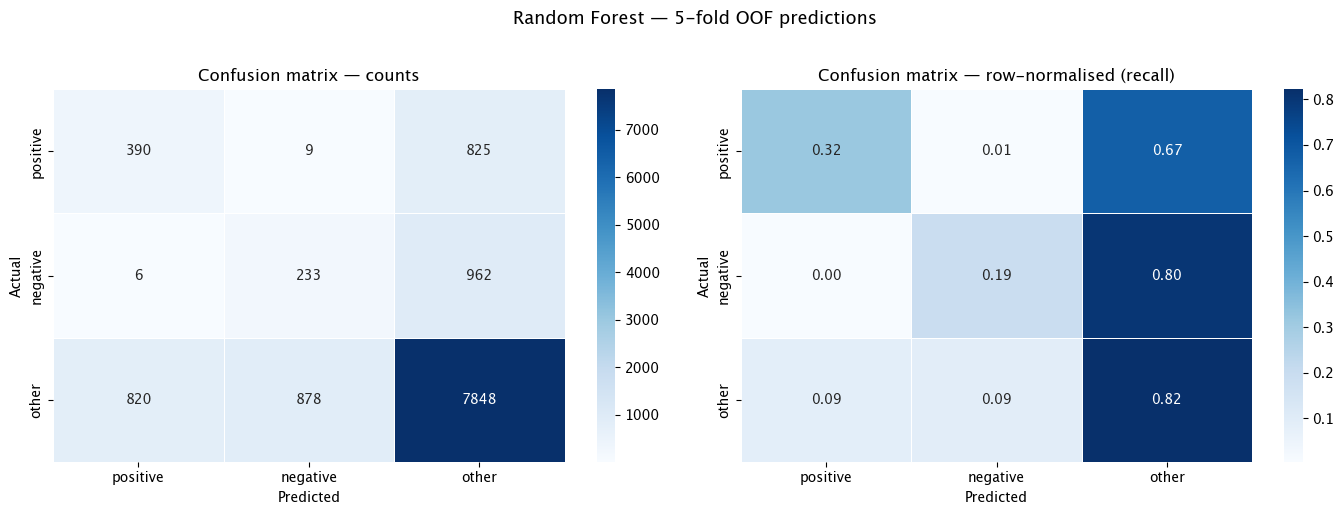

              precision    recall  f1-score   support

    positive       0.32      0.32      0.32      1224
    negative       0.21      0.19      0.20      1201
       other       0.81      0.82      0.82      9546

    accuracy                           0.71     11971
   macro avg       0.45      0.44      0.45     11971
weighted avg       0.70      0.71      0.71     11971



In [51]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

y_true = features['class3']
y_pred = features['pred_RandomForest']

cm_counts = confusion_matrix(y_true, y_pred, labels=ORDER_3)
cm_norm   = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)  # row-normalised (recall)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, fmt in zip(
    axes,
    [cm_counts, cm_norm],
    ['Confusion matrix — counts', 'Confusion matrix — row-normalised (recall)'],
    ['d', '.2f']
):
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=ORDER_3, yticklabels=ORDER_3,
        linewidths=0.5, ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.suptitle('Random Forest — 5-fold OOF predictions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, labels=ORDER_3, target_names=ORDER_3))